In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [169]:
df = pd.read_excel('Cleaned Data.xlsx')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Age                                                           500 non-null    object
 1   Gender                                                        500 non-null    object
 2   Education                                                     500 non-null    object
 3   Annual income (including any social welfare programs) in USD  500 non-null    int64 
 4   I am unemployed                                               500 non-null    object
 5   I identify as having a mental illness                         500 non-null    object
 6   I have my regular access to the internet                      500 non-null    object
 7   I am legally disabled                                         500 non-null    ob

In [170]:
#renaming Columns

df.rename(columns={'I identify as having a mental illness':'MentallyIll'},
inplace =True)

df.rename(columns={'I am unemployed':'Unemployed'}, inplace =True)

df.MentallyIll

# Show all column values
#pd.set_option('display.max_columns', None)
#Delete Identifying columns and other unneeded info
#cols = list(range(0,9))
#df.drop(df.columns[cols], axis=1, inplace=True)
#Replace Yes and No's with 0s and 1s, replace NaNs

df = df.replace(to_replace=['No', 'Yes'], value=[0, 1])

df = df.fillna(0)

In [171]:
#remove first row of response
df = df.iloc[1:]

df.head(5)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 1 to 499
Data columns (total 18 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Age                                                           499 non-null    object
 1   Gender                                                        499 non-null    object
 2   Education                                                     499 non-null    object
 3   Annual income (including any social welfare programs) in USD  499 non-null    int64 
 4   Unemployed                                                    499 non-null    int64 
 5   MentallyIll                                                   499 non-null    int64 
 6   I have my regular access to the internet                      499 non-null    int64 
 7   I am legally disabled                                         499 non-null    in

In [172]:
#renaming income columns

df.rename(columns={'Annual income (including any social welfare programs) in USD':'Income'}, inplace =True)

income = pd.to_numeric(df.Income, errors='coerce')

#Income stats of all respondents

income.describe()

count      499.000000
mean     55202.951904
std      25516.448675
min      10060.000000
25%      34308.000000
50%      55028.000000
75%      77331.000000
max      99613.000000
Name: Income, dtype: float64

<Axes: xlabel='count', ylabel='Education'>

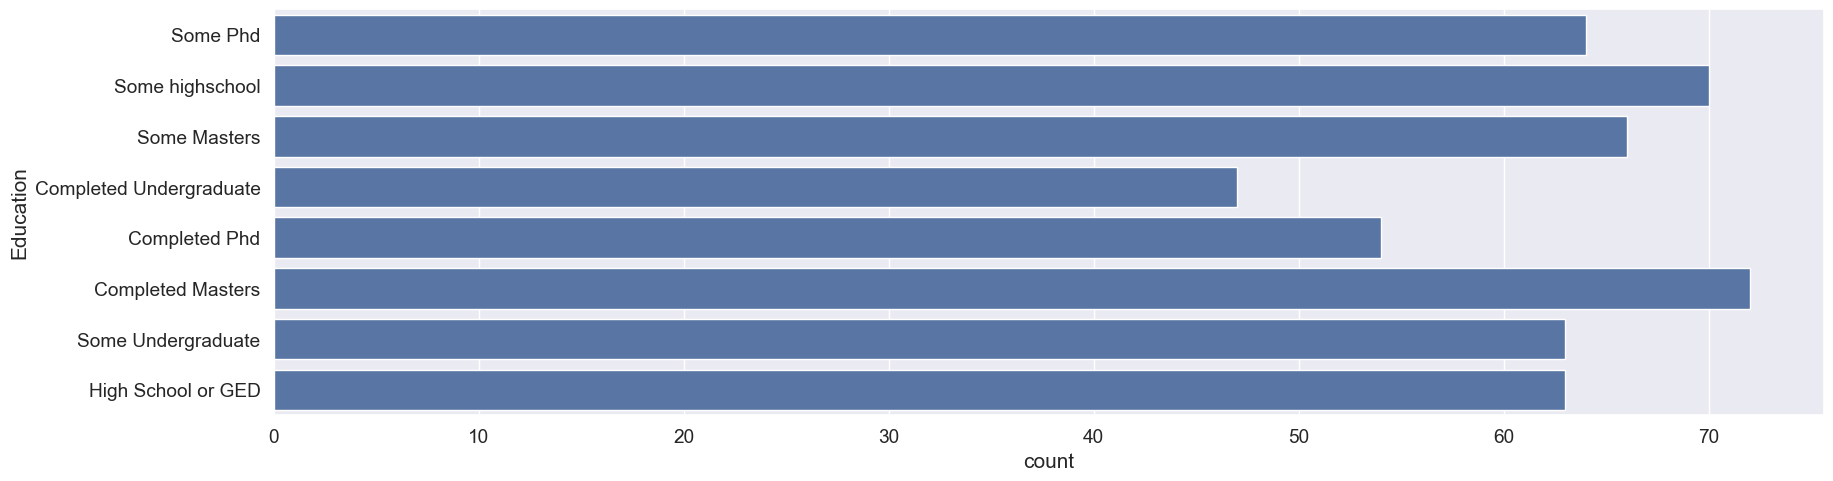

In [173]:
a4_dims = (20, 5.27)

fig, ax = plt.subplots(figsize=a4_dims)

sns.countplot(df.Education)

#sns.countplot(ill)

In [174]:
edu = df.Education.to_frame().to_records()

df.columns

Index(['Age', 'Gender', 'Education', 'Income', 'Unemployed', 'MentallyIll',
       'I have my regular access to the internet', 'I am legally disabled',
       'I am currently employed at least part-time', 'I receive food stamps',
       'Anxiety', 'Depression', 'Tiredness', 'Mood swings', 'Panic attacks',
       'Compulsive behavior', 'Obsessive thinking', 'Lack of concentration'],
      dtype='object')

In [175]:
mental = df.MentallyIll.to_frame().to_records()

income = df.Income.to_frame().to_records()

unemployed = df.Unemployed.to_frame().to_records()

gender = df.Gender.to_frame().to_records()

age = df.Age.to_frame().to_records()

sixty, fifty, thirty, twenty = [], [], [], []

In [176]:
for i in age:
 if i[1] == '> 60':
  sixty.append((i[0], income[i[0]-1][1], unemployed[i[0]-1][1]))

 elif i[1] == '45-60':
  fifty.append((i[0], income[i[0]-1][1], unemployed[i[0]-1][1]))

 elif i[1] == '30-44':
  thirty.append((i[0], income[i[0]-1][1], unemployed[i[0]-1][1]))
  
 elif i[1] == '18-29':
#Implementation
  twenty.append((i[0], income[i[0]-1][1], unemployed[i[0]-1][1]))

age_list = [sixty, fifty, thirty, twenty]

title_age_list = ['Sixties', 'Fifties', 'Thirties', 'Twenties']

j = 0;

In [177]:
for i in age_list:
 
#sort by income

 x_val = sorted([x[1] for x in i if pd.notna(x[1])]) # Filter out NaN values

 unemp = [x[2] for x in i if pd.notna(x[1])] # Filter corresponding unemp values

#convert income to integers

x_int = []

In [178]:
for val in x_val:
    try:
        x_int.append(int(val))
    except ValueError:
        pass # Skip values that cannot be converted to int
#Removing plots to reduce kernel size
#a4_dims = (20, 4)
#fig, ax = plt.subplots(figsize=a4_dims)
#g = sns.scatterplot(x = x_int, y=unemp)
#ax.set(xlabel='Income', ylabel='Unemployed')
#plt.title(title_age_list[j])

In [179]:
if len(unemp) > 0: # Avoid division by zero if unemp list is empty

  print(title_age_list[j], '-- Percent Unemployed:',
        
  sum(unemp)/len(unemp))

j = j+1
#separate and regroup data based on education 

completed_masters, completed_undergrad, high_school, some_Phd, completed_Phd, some_highschool, some_undergrad, some_masters = [], [], [], [],[], [], [], []


Sixties -- Percent Unemployed: 0.36065573770491804


In [180]:
for i in edu:
 if i[1] == 'Completed Masters':
  completed_masters.append((i[0], mental[i[0]-1][1], income[i[0]-
  1][1], unemployed[i[0]-1][1], gender[i[0]-1][1], age[i[0]-1][1]))

 elif i[1] == 'Completed Undergraduate':
  completed_undergrad.append((i[0], mental[i[0]-1][1], income[i[0]-
  1][1], unemployed[i[0]-1][1], gender[i[0]-1][1], age[i[0]-1][1]))

 elif i[1] == 'High School or GED':
  high_school.append((i[0], mental[i[0]-1][1], income[i[0]-1][1],
  unemployed[i[0]-1][1], gender[i[0]-1][1], age[i[0]-1][1]))

 elif i[1] == 'Some Phd':
  some_Phd.append((i[0], mental[i[0]-1][1], income[i[0]-1][1],
  unemployed[i[0]-1][1], gender[i[0]-1][1], age[i[0]-1][1]))

 elif i[1] == 'Completed Phd':
  completed_Phd.append((i[0], mental[i[0]-1][1], income[i[0]-1][1],
  unemployed[i[0]-1][1], gender[i[0]-1][1], age[i[0]-1][1]))

 elif i[1] == 'Some highschool':
  some_highschool.append((i[0], mental[i[0]-1][1], income[i[0]-1][1],
  unemployed[i[0]-1][1], gender[i[0]-1][1], age[i[0]-1][1]))

 elif i[1] == 'Some Undergraduate':
  some_undergrad.append((i[0], mental[i[0]-1][1], income[i[0]-1][1],
  unemployed[i[0]-1][1], gender[i[0]-1][1], age[i[0]-1][1]))
  
 else:
  some_masters.append((i[0], mental[i[0]-1][1], income[i[0]-1][1],
  unemployed[i[0]-1][1], gender[i[0]-1][1], age[i[0]-1][1]))

In [181]:
#Plot data, different graphs for different education levels

tot_list = [completed_masters, completed_undergrad, high_school,
some_Phd, completed_Phd, some_highschool, some_undergrad,
some_masters]

title_list = ['Completed Masters', 'Completed Undergrad', 'High School',
'Some PhD', 'Completed PhD', 'Some Highschool', 'Some Undergrad',
'Some Masters']

In [182]:
for j, i in enumerate(tot_list):

#sort by income

    x_val = sorted([x[2] for x in i if pd.notna(x[2])]) # Filter out NaN values

    y_val = [x[1] for x in i if pd.notna(x[2])] # Filter corresponding y_val

    unemp = [x[3] for x in i if pd.notna(x[2])] # Filter corresponding unemp

    gend = [x[4] for x in i if pd.notna(x[2])] # Filter corresponding gend

    age = [x[5] for x in i if pd.notna(x[2])] # Filter corresponding 
    

In [183]:
#convert income to integers

x_int = []
for val in x_val:
    try:
        x_int.append(int(val))
    except ValueError:
        pass # Skip values that cannot be converted to int

In [184]:
#convert binary employment to text labels

for k in range(len(unemp)): # Changed loop variable to k
 
 if unemp[k] == 1:
  unemp[k] = 'Unemployed'

 elif unemp[k] == 0:
  unemp[k] = 'Employed'

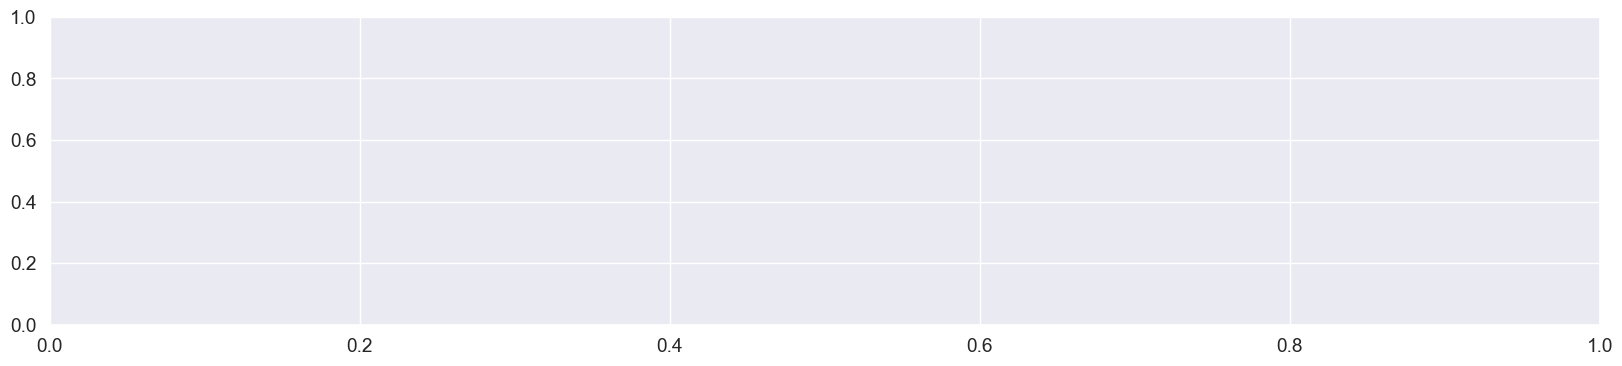

In [185]:
a4_dims = (20, 4)

fig, ax = plt.subplots(figsize=a4_dims)

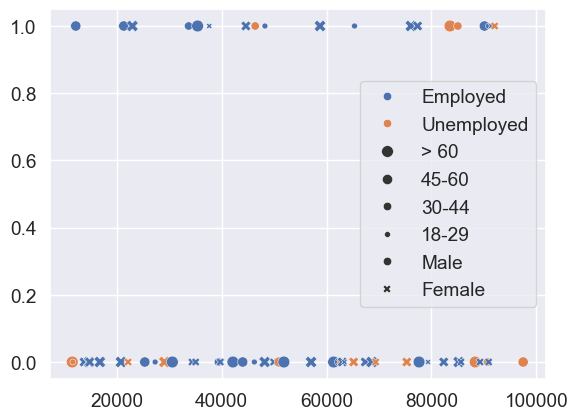

In [186]:
g = sns.scatterplot(x = x_int, y=y_val,
hue=unemp, hue_order = ('Employed', 'Unemployed'),
style=gend,
size=age, size_order = ('> 60', '45-60', '30-44','18-29'))

Text(0.5, 1.0, 'Some Masters')

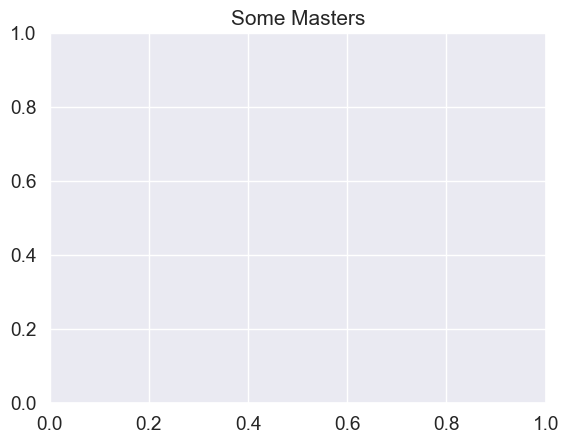

In [187]:
ax.set(xlabel='Income', ylabel='Mentally Ill')

plt.title(title_list[j])

In [188]:
#use new dataframe for ML part

df2 = df.copy()

In [189]:
#remove last 3 irrelevant columns

df2 = df2.iloc[:, :-3]

In [190]:
#replace issues with binary representations

df2 = df2.replace(['Lack of concentration','Anxiety', 'Depression',
'Obsessive thinking', 'Panic attacks', 'Compulsive behavior',
'Mood swings', 'Tiredness'], 1)

In [191]:
#replace gender -> Male = 1, Female = 0

df2 = df2.replace(to_replace=['Female', 'Male'], value=[0, 1])

#replace age with median

df2 = df2.replace(to_replace=['> 60', '45-60', '30-44','18-29'], value=[65,
52, 37, 23])

#replace education with ranking, 0 is lowest educated 7 is highest

df2 = df2.replace(to_replace=['Completed Phd', 'Some Phd', 'Completed Masters','Some Masters','Completed Undergraduate', 'Some Undergraduate','High School or GED', 'Some highschool'],value=[7, 6, 5, 4, 3, 2, 1, 0])


In [192]:
#Fully cleaned data

df2.head(5)

,Age,Gender,Education,Income,Unemployed,MentallyIll,I have my regular access to the internet,I am legally disabled,I am currently employed at least part-time,I receive food stamps,Anxiety,Depression,Tiredness,Mood swings,Panic attacks
1,65,1,6,51157,1,0,1,0,0,0,1,0,0,0,0
2,23,1,0,64917,0,1,1,0,1,0,1,1,0,1,0
3,52,0,0,93122,0,1,1,0,1,0,0,1,1,0,1
4,52,1,0,34519,0,0,1,0,0,1,1,1,0,0,0
5,65,1,4,97487,1,0,1,0,0,0,0,0,0,0,0


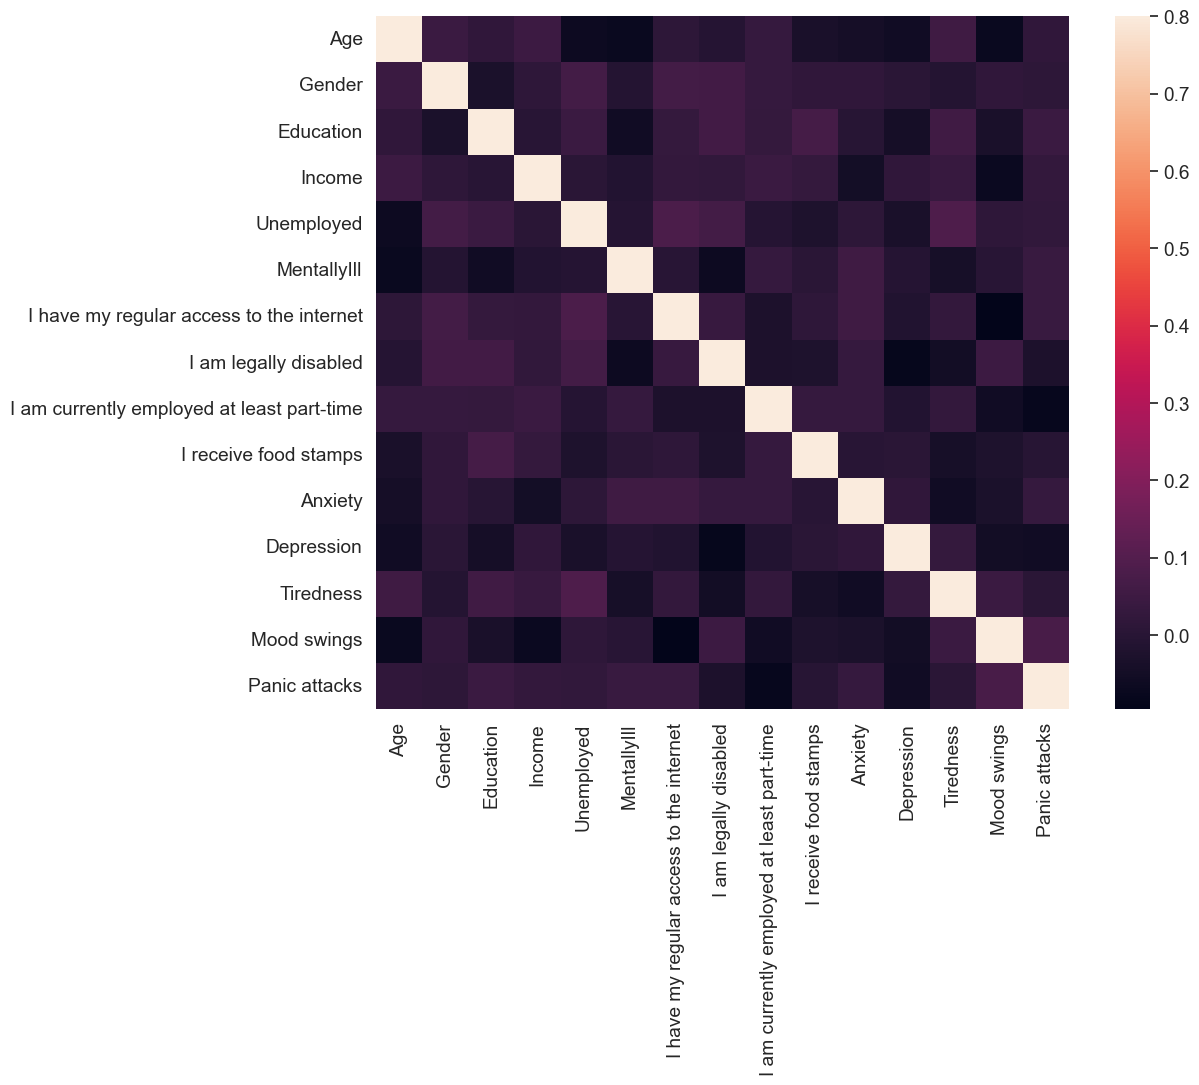

In [193]:
#Covariance Matrix
corrmat = df2.corr()

f, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(corrmat, vmax=.8, square=True);

plt.show()


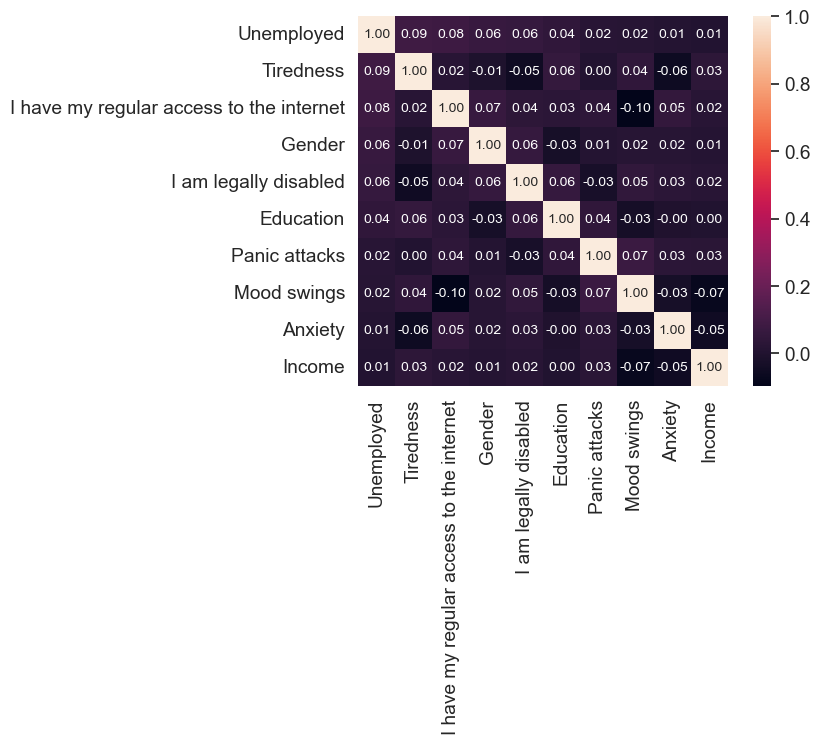

In [194]:
#Unemployed correlation matrix

k = 10 #number of variables for heatmap

cols = corrmat.nlargest(k, 'Unemployed')['Unemployed'].index

cm = np.corrcoef(df2[cols].values.T)

sns.set(font_scale=1.25)

hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f',
annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)

plt.show()

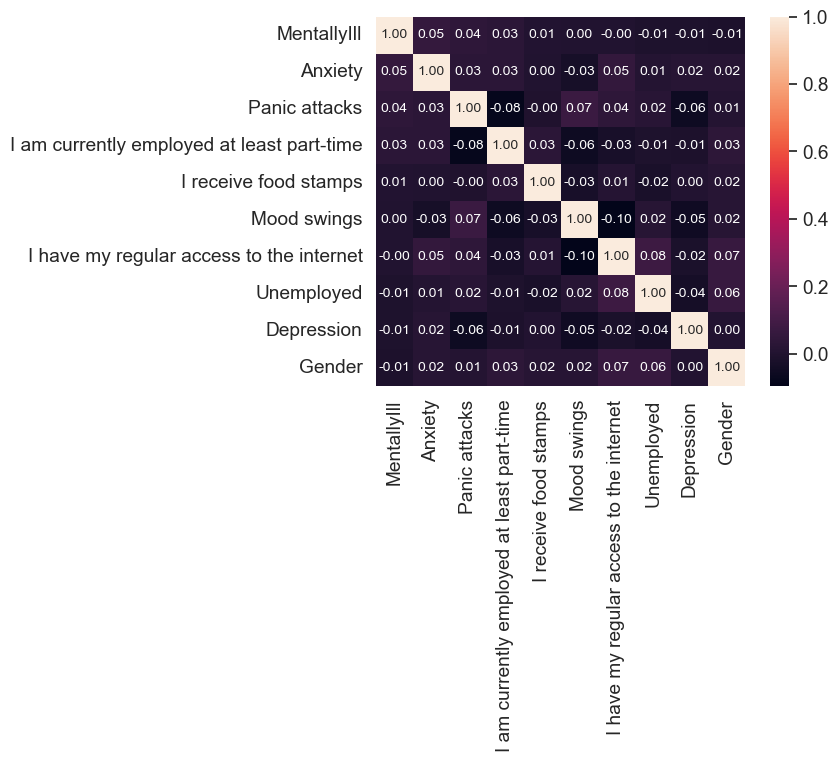

In [195]:
#MentallyIll correlation matrix

k = 10 #number of variables for 

cols = corrmat.nlargest(k, 'MentallyIll')['MentallyIll'].index

cm = np.corrcoef(df2[cols].values.T)

sns.set(font_scale=1.25)

hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f',
annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)

plt.show()

In [196]:
#Begin Random Forest

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

#set target and drop from data

df3 = df2.copy()

df4 = df2.copy()

df5 = df2.copy()

target=df2['MentallyIll']

df2.drop(['MentallyIll'],axis=1,inplace=True)

X = df2

X_train, X_test, y_train, y_test = train_test_split(X,target, test_size=0.2,
random_state=0)

forest = RandomForestClassifier(max_depth=10, random_state=0)

forest.fit(X_train, y_train)

print(forest.score(X_test,y_test))

#print(forest.score(X_train, y_train))

0.47


<Axes: xlabel='feature'>

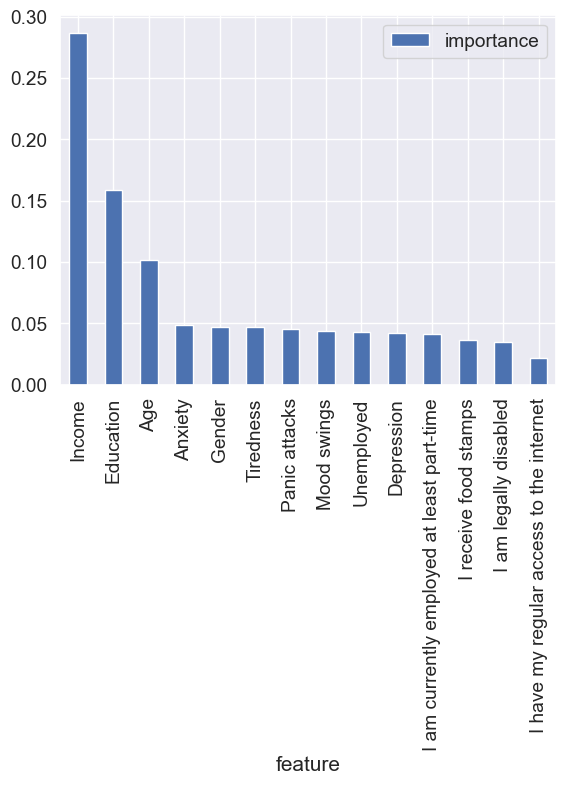

In [197]:
#Important Features

importances = pd.DataFrame({'feature':X_train.columns,'importance':np.round(forest.feature_importances_,3)})

importances = importances.sort_values('importance',ascending=False).set_index('feature')

importances.plot.bar()

In [198]:
#Confusion Matrix

from sklearn.model_selection import cross_val_predict

from sklearn.metrics import confusion_matrix

predictions = cross_val_predict(forest, X_train, y_train, cv=3)

confusion_matrix(y_train, predictions)

#183 correctly classified as not mentally ill, 19 wrongly classified as not mentally ill
#26 people wrongly classified as mentally ill, 39 correctly classified as mentally ill

array([[214,  39],
       [125,  21]])

In [199]:
#Recall and Precision

from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_train, predictions))

print("Recall:",recall_score(y_train, predictions))

from sklearn.metrics import f1_score

f1_score(y_train, predictions)

Precision: 0.35
Recall: 0.14383561643835616


0.20388349514563106

In [200]:
#Precision Recall Curve

from sklearn.metrics import precision_recall_curve

# getting the probabilities of our predictions

y_scores = forest.predict_proba(X_train)

y_scores = y_scores[:,1]

precision, recall, threshold = precision_recall_curve(y_train, y_scores)

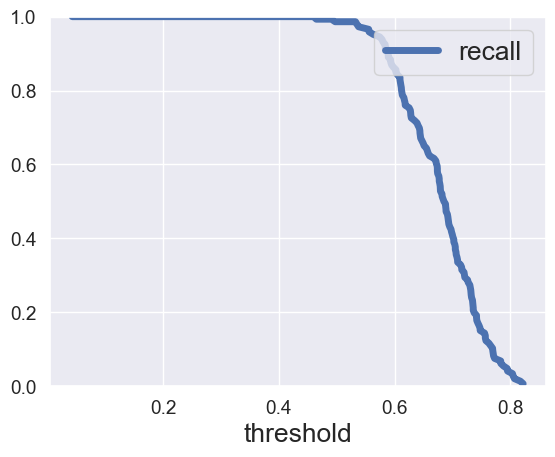

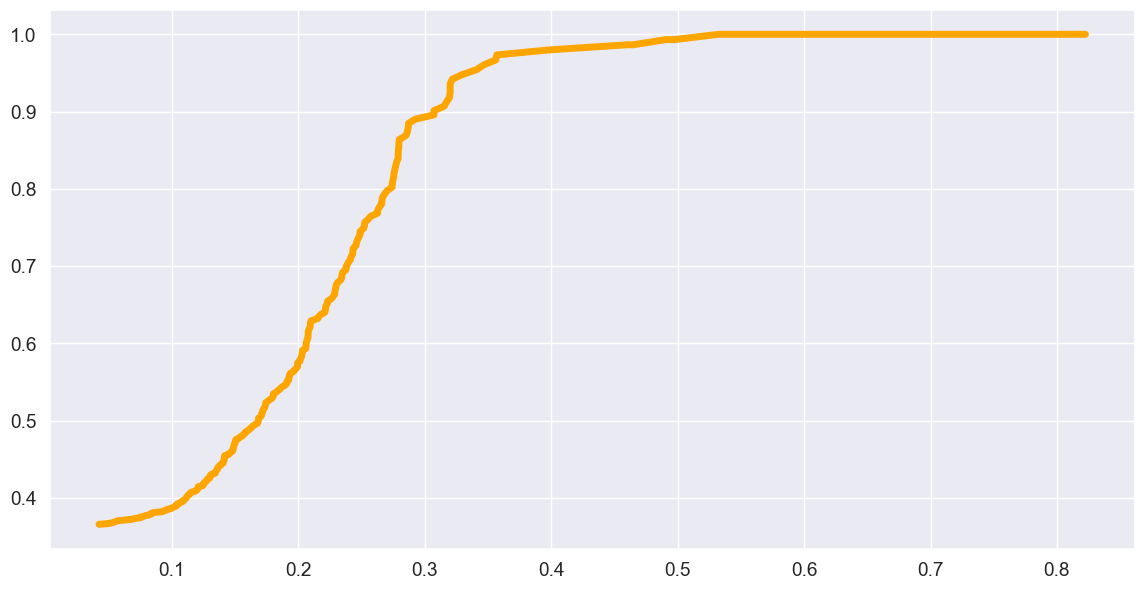

In [201]:
def plot_precision_and_recall(precision, recall, threshold):

    plt.plot(threshold, precision[:-1], "orange", label="precision",
    linewidth=5)

plt.plot(threshold, recall[:-1], "b", label="recall", linewidth=5)

plt.xlabel("threshold", fontsize=19)

plt.legend(loc="upper right", fontsize=19)

plt.ylim([0, 1])

plt.figure(figsize=(14, 7))

plot_precision_and_recall(precision, recall, threshold)
    
plt.show()

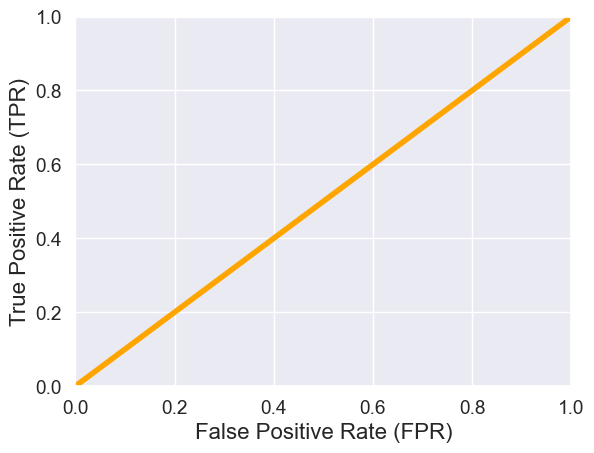

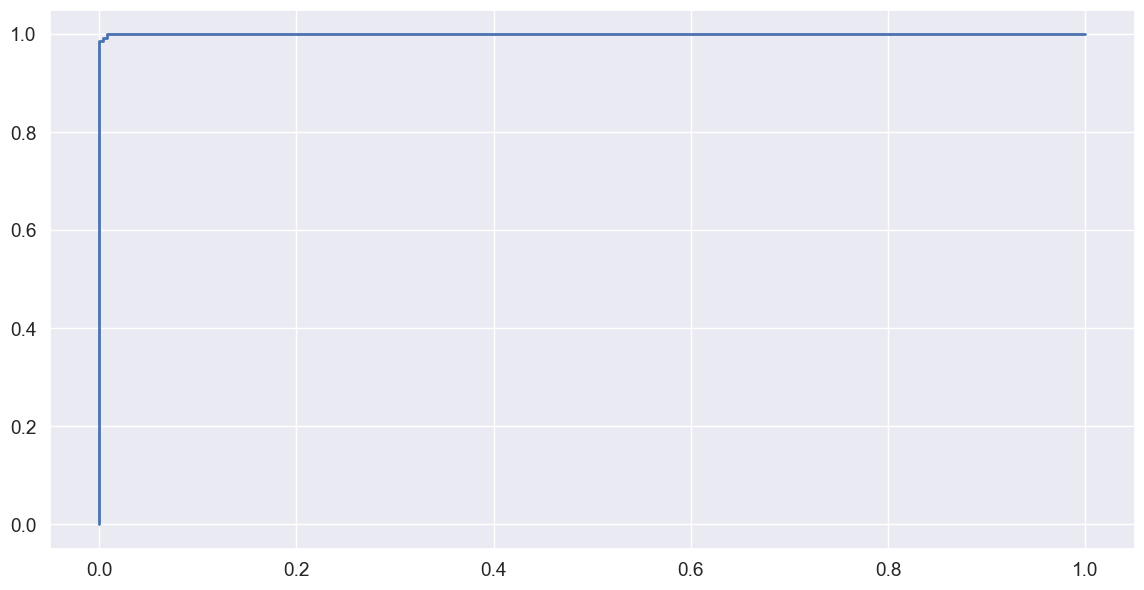

In [202]:
#ROC AUC Curve

from sklearn.metrics import roc_curve

# compute true positive rate and false positive rate

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train,
y_scores)

# plotting them against each other

def plot_roc_curve(false_positive_rate, true_positive_rate, label=None):
 
  plt.plot(false_positive_rate, true_positive_rate, linewidth=2,
 label=label)

plt.plot([0, 1], [0, 1], 'orange', linewidth=4)

plt.axis([0, 1, 0, 1])

plt.xlabel('False Positive Rate (FPR)', fontsize=16)

plt.ylabel('True Positive Rate (TPR)', fontsize=16)

plt.figure(figsize=(14, 7))

plot_roc_curve(false_positive_rate, true_positive_rate)

plt.show()

In [203]:
from sklearn.metrics import roc_auc_score

r_a_score = roc_auc_score(y_train, y_scores)

print("ROC-AUC-Score:", r_a_score)

#dropping said columns, leaving tiredness and lack of concentration
#df3.drop(['I have been hospitalized before for my mental illness'],axis=1,inplace=True)
#df3.drop(['How many days were you hospitalized for your mental illness'],axis=1,inplace=True)
#df3.drop(['I am legally disabled'],axis=1,inplace=True)
#df3.drop(['How many times were you hospitalized for your mental illness'],axis=1,inplace=True)
#df3.drop(['depression'],axis=1,inplace=True)
#df3.drop(['anxiety'],axis=1,inplace=True)
#df3.drop(['Obsessive'],axis=1,inplace=True)
#df3.drop(['panic attack'],axis=1,inplace=True)
#df3.drop(['mood swings'],axis=1,inplace=True)
#df3.drop(['compulsive'],axis=1,inplace=True)
#df3.head(5)
#target=df3['MentallyIll']
#df3.drop(['MentallyIll'],axis=1,inplace=True)

X = df3

X_train, X_test, y_train, y_test = train_test_split(X,target, test_size=0.2,
random_state=0)

forest3 = RandomForestClassifier(max_depth=5, random_state=0)

forest3.fit(X_train, y_train)

print(forest3.score(X_test,y_test))

#print(forest.score(X_train, y_train))

ROC-AUC-Score: 0.9999187828252748
1.0


<Axes: xlabel='feature'>

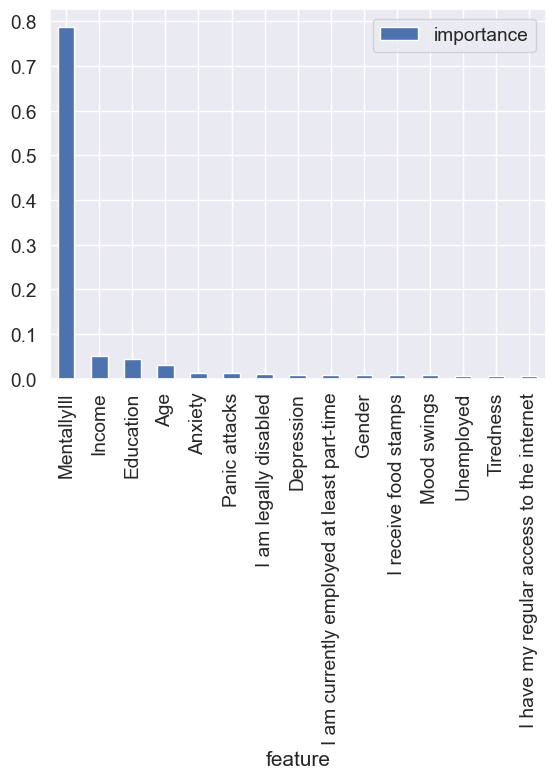

In [204]:
#Important Features

importances = pd.DataFrame({'feature':X_train.columns,'importance':np.round(forest3.feature_importances_,3)})

importances =importances.sort_values('importance',ascending=False).set_index('feature')

importances.plot.bar()

In [205]:
#Confusion Matrix

from sklearn.model_selection import cross_val_predict

from sklearn.metrics import confusion_matrix

predictions = cross_val_predict(forest3, X_train, y_train, cv=3)

confusion_matrix(y_train, predictions)

array([[253,   0],
       [  0, 146]])

In [206]:
from sklearn.metrics import roc_auc_score

#y_scores = forest3.predict_proba(X_train)
#y_scores = y_scores[:,1]

r_a_score = roc_auc_score(y_train, y_scores)

print("ROC-AUC-Score:", r_a_score)

#Drop income and current employment features
#df4.drop(['Income'],axis=1,inplace=True)
#df4.drop(['I am currently employed at least part- time'],axis=1,inplace=True)
#df4.drop(['Annual income from social welfare programs'],axis=1,inplace=True)
#df4.drop(['I receive food stamps'],axis=1,inplace=True)
#target=df4['Unemployed']
#df4.drop(['Unemployed'],axis=1,inplace=True)
#df4.head(5)

X = df4

X_train, X_test, y_train, y_test = train_test_split(X,target, test_size=0.2,
random_state=0)

forest4 = RandomForestClassifier(max_depth=15, random_state=0)

forest4.fit(X_train, y_train)

#Accuracy
print(forest4.score(X_test,y_test))

ROC-AUC-Score: 0.9999187828252748
1.0


<Axes: xlabel='feature'>

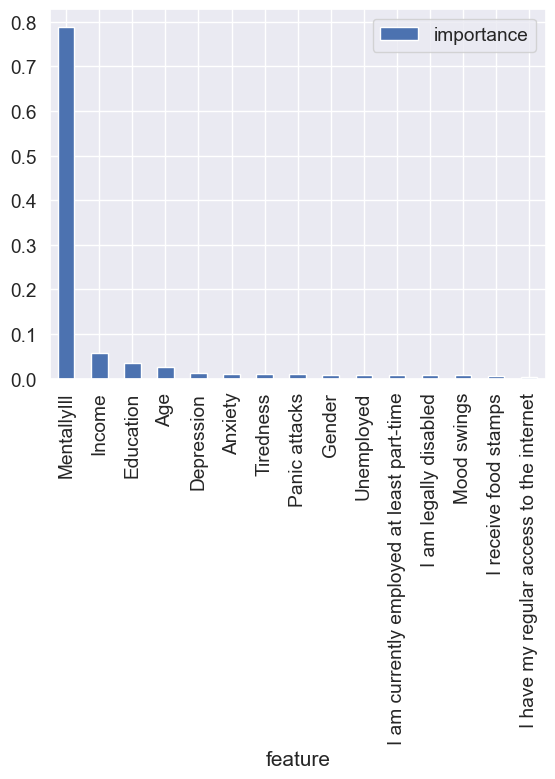

In [207]:
#Important Features

importances = pd.DataFrame({'feature':X_train.columns,'importance':np.round(forest4.feature_importances_,3)})

importances = importances.sort_values('importance',ascending=False).set_index('feature')

importances.plot.bar()

In [208]:
from sklearn.metrics import roc_auc_score

y_scores = forest4.predict_proba(X_train)

y_scores = y_scores[:,1]

r_a_score = roc_auc_score(y_train, y_scores)

print("ROC-AUC-Score:", r_a_score)

ROC-AUC-Score: 1.0


In [209]:
#Drop all non mental health features

df5.drop(['Income'],axis=1,inplace=True)

df5.drop(['I am currently employed at least part-time'],axis=1,inplace=True)

df5.drop(['I receive food stamps'],axis=1,inplace=True)

df5.drop(['Education'],axis=1,inplace=True)

df5.drop(['I am legally disabled'],axis=1,inplace=True)

df5.drop(['I have my regular access to the internet'],axis=1,inplace=True)

#df5.drop(['Total length of any gaps in my resume in months.'],axis=1,inplace=True)

df5.drop(df5.columns[3], axis=1, inplace=True)

#df5.drop(['I read outside of work and school'],axis=1,inplace=True)
#df5.drop(['I am on section 8 housing'],axis=1,inplace=True)

df5.drop(['Age'],axis=1,inplace=True)

df5.drop(['Gender'],axis=1,inplace=True)

target=df5['Unemployed']

df5.drop(['Unemployed'],axis=1,inplace=True)

#df5.head(5)

In [210]:
X = df5

X_train, X_test, y_train, y_test = train_test_split(X,target, test_size=0.2,
random_state=0)

forest5 = RandomForestClassifier(max_depth=15, random_state=0)

forest5.fit(X_train, y_train)

#Accuracy

print(forest5.score(X_test,y_test))

0.66


<Axes: xlabel='feature'>

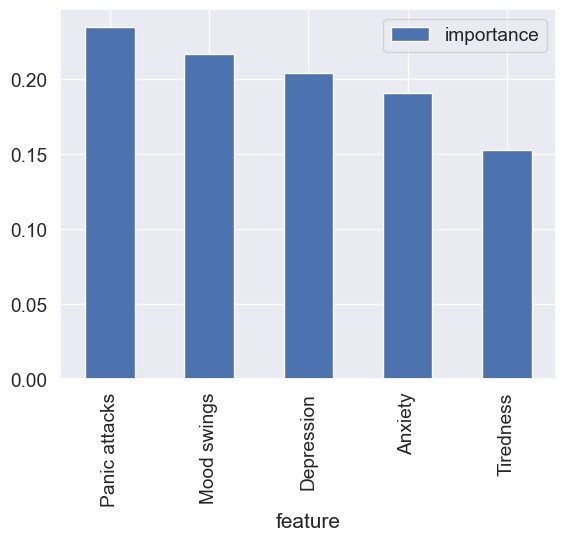

In [211]:
#Important Features

importances = pd.DataFrame({'feature':X_train.columns,'importance':np.round(forest5.feature_importances_,3)})

importances = importances.sort_values('importance',ascending=False).set_index('feature')

importances.plot.bar()

In [212]:
from sklearn.metrics import roc_auc_score

y_scores = forest5.predict_proba(X_train)

y_scores = y_scores[:,1]

r_a_score = roc_auc_score(y_train, y_scores)

print("ROC-AUC-Score:", r_a_score)

ROC-AUC-Score: 0.6534976056252653


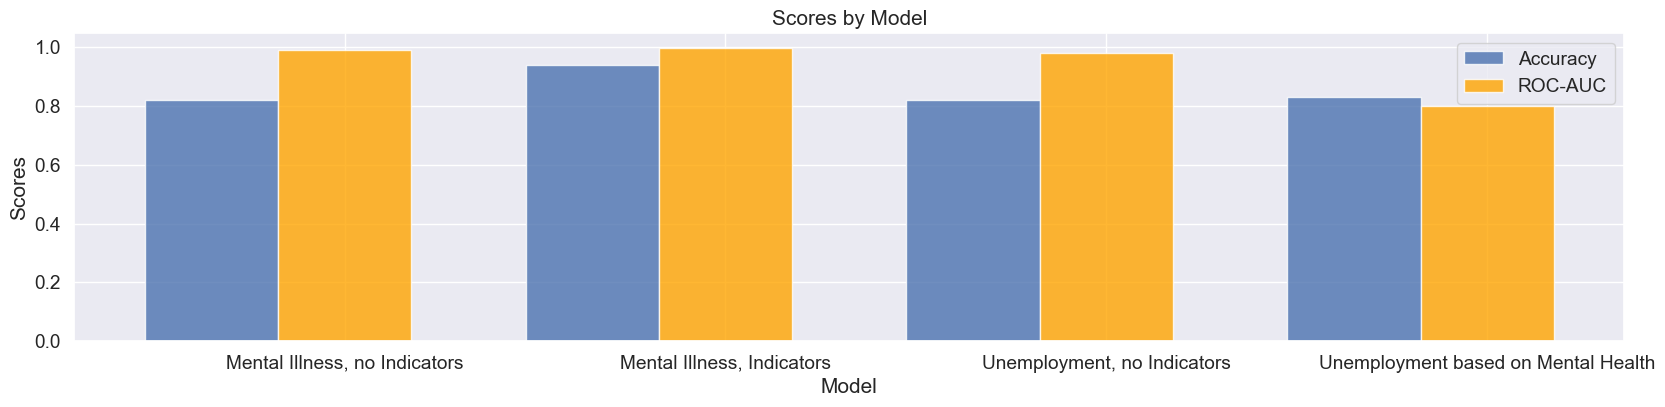

<Figure size 3000x700 with 0 Axes>

In [213]:
# data to plot

n_groups = 4

accuracy = (0.82, 0.94, 0.82, 0.83)

auc_roc = (0.9899, 0.997, 0.98, 0.80)

# create plot

a4_dims = (20, 4)

fig, ax = plt.subplots(figsize=a4_dims)

index = np.arange(n_groups)

bar_width = 0.35

opacity = 0.8

rects1 = plt.bar(index, accuracy, bar_width,
alpha=opacity,
color='b',
label='Accuracy')

rects2 = plt.bar(index + bar_width, auc_roc, bar_width,
alpha=opacity,
color='orange',
label='ROC-AUC')

plt.xlabel('Model')

plt.ylabel('Scores')

plt.title('Scores by Model')

plt.xticks(index + bar_width, ('Mental Illness, no Indicators', 'Mental Illness, Indicators',
                               'Unemployment, no Indicators',
                               'Unemployment based on Mental Health'))

plt.legend()

plt.figure(figsize=(30, 7))

plt.show()